В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [283]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [284]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [285]:
medical_df = pd.read_csv("drive/MyDrive/ML learning/2_1/medical-charges.csv")
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [286]:
X = non_smoker_df.age

y = non_smoker_df.charges

**1. Метод МНК**

In [287]:
def normal_equations(X, y):
  theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
  return theta

In [288]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [289]:
MNK_coef = normal_equations(X_with_intercept, y)

In [290]:
MNK_coef

array([-2091.42055657,   267.24891283])

In [291]:
y_pred_MNK = np.dot(X_with_intercept, MNK_coef)

In [292]:
rmse_MNK = np.sqrt(mean_squared_error(y, y_pred_MNK))

rmse_MNK

np.float64(4662.505766636395)

**2. Градієнтний спуск**

In [293]:
def full_batch_gradient_descent(X, y, lr, epochs):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X)
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [294]:
m1, b1, errors = full_batch_gradient_descent(X, y, lr=0.01, epochs=100)

m2, b2, errors = full_batch_gradient_descent(X, y, lr=0.001, epochs=100)

m3, b3, errors = full_batch_gradient_descent(X, y, lr=0.0001, epochs=100)

In [295]:
print('При lr=0.01 коефіцієнт m =', m1, 'коефіцієнт b =', b1)
print('При lr=0.001 коефіцієнт m =', m2, 'коефіцієнт b =', b2)
print('При lr=0.0001 коефіцієнт m =', m3, 'коефіцієнт b =', b3)

При lr=0.01 коефіцієнт m = -3.138599095395552e+155 коефіцієнт b = -7.066740077737092e+153
При lr=0.001 коефіцієнт m = -1.3967624262082842e+42 коефіцієнт b = -3.1448925830775484e+40
При lr=0.0001 коефіцієнт m = 220.15455659787733 коефіцієнт b = 0.21295826871672194


При learning rate 0.01 та 0.001 значення коефіцієнтів получилися дуже великими, а при 0.0001 виглядають адекватними. Тому для прогнозу встановлюємо це значення параметру

In [296]:
m3, b3

(np.float64(220.15455659787733), np.float64(0.21295826871672194))

In [297]:
y_pred_FBGD = m3 * X + b3

In [298]:
rmse_FBGD = np.sqrt(mean_squared_error(y, y_pred_FBGD))

rmse_FBGD

np.float64(4715.349747703003)

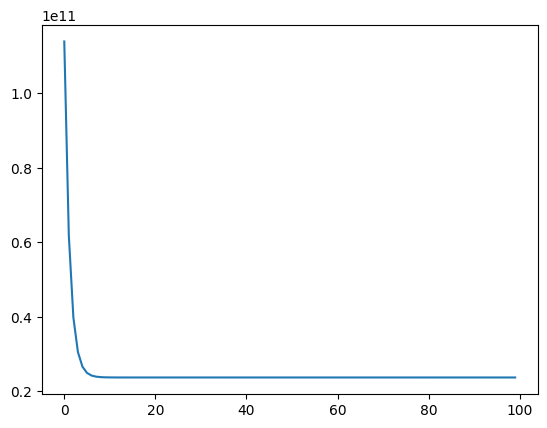

In [299]:
plt.plot(errors)

**3. scikit-learn.LinearRegression**

In [300]:
X_frame = X.to_frame()

In [301]:
lin_reg = LinearRegression()

lin_reg.fit(X_frame, y)

LinearRegression()

In [302]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [303]:
y_pred_sklearn = lin_reg.predict(X_frame)

In [304]:
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred_sklearn))

rmse_sklearn

np.float64(4662.505766636395)

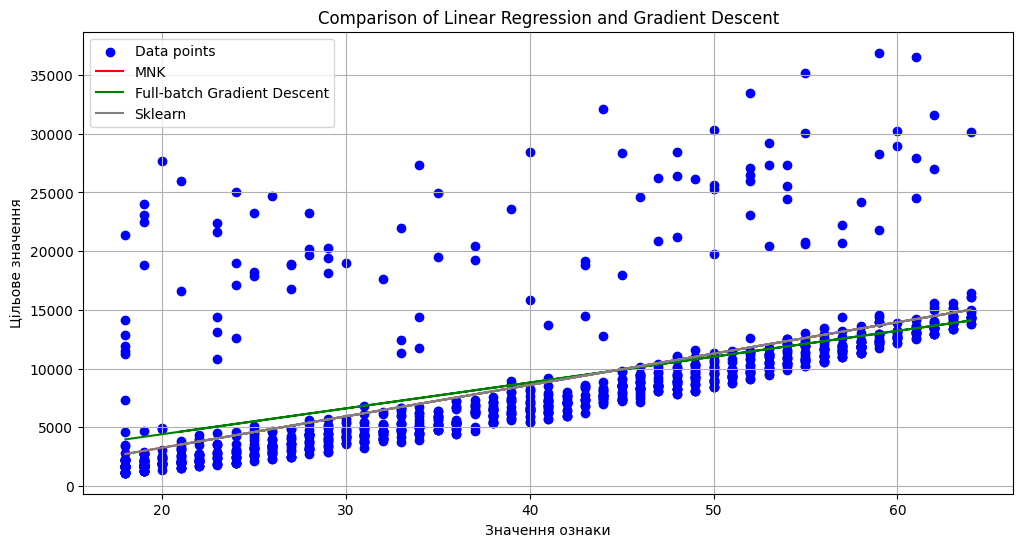

In [305]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred_MNK, color='red', label='MNK')
plt.plot(X, y_pred_FBGD, color='green', label='Full-batch Gradient Descent')
plt.plot(X, y_pred_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()


**Висновок**

Метод МНК і використання лінійної регресії з sklearn дали одинаковий результат, що і повинно було получитися, а метод Full-Batch градієнтний спуск дав трішки гірший результат. Значення помилки RMSE для нього вище. Знайдені параметри моделі близькими дають більш точний прогноз поірвняно з моїми найкращими припущеннями

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [306]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X_smoker = smoker_df.age.to_frame()

y_smoker = smoker_df.charges

In [307]:
lin_reg_smoker = lin_reg.fit(X_smoker, y_smoker)

In [308]:
lin_reg.coef_, lin_reg.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [312]:
y_smoker_pred = lin_reg.predict(X_smoker)

In [313]:
rmse_smoker = np.sqrt(mean_squared_error(y_smoker, y_smoker_pred))

rmse_smoker

np.float64(10711.00334810241)

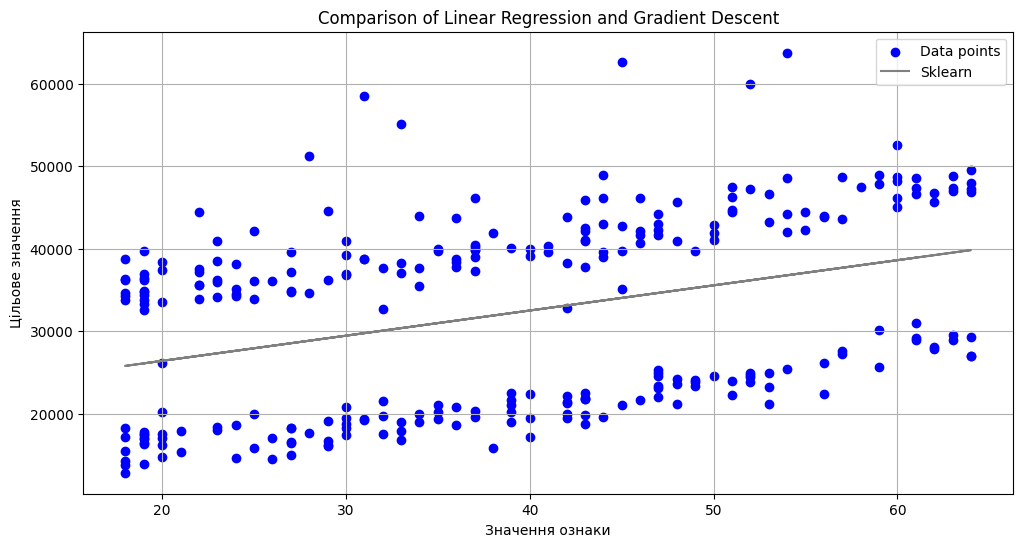

In [314]:
plt.figure(figsize=(12, 6))
plt.scatter(X_smoker, y_smoker, color='blue', label='Data points')
plt.plot(X_smoker, y_smoker_pred, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()


**Висновок**

Ця модель погана для цієї задачі і в компанії я б її не використовував, хоч тренд лінії правильний, але тут чітко видно два кластера даних, які ймовірно розділяє якась інша змінна, точки фактичних даних знаходяться досить далеко від побудованої лінії, значення RMSE також велике